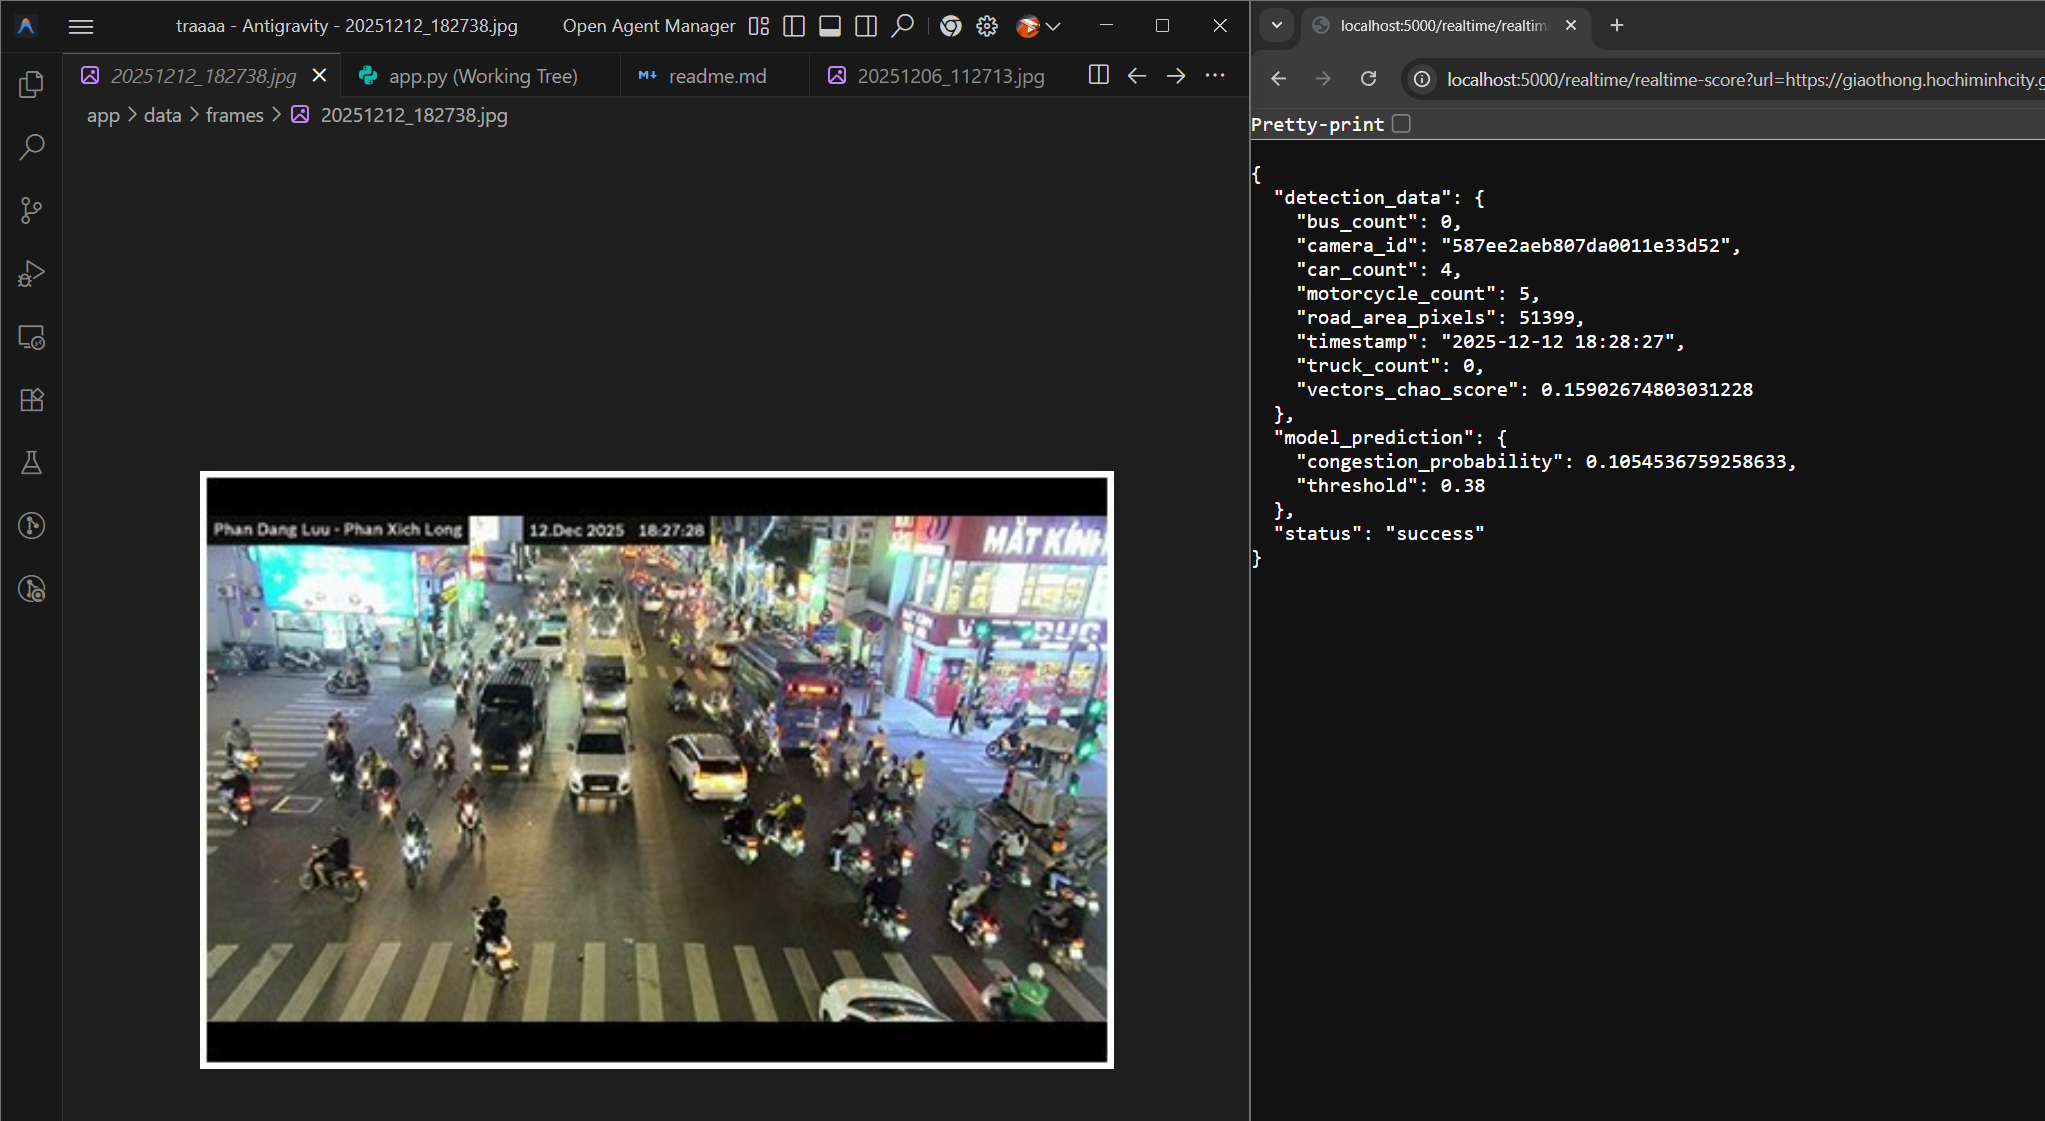

{
  "detection_data": {
    "bus_count": 0,
    "camera_id": "587ee2aeb807da0011e33d52",
    "car_count": 11,
    "motorcycle_count": 8,
    "road_area_pixels": 3139,
    "timestamp": "2025-12-26 11:28:13",
    "truck_count": 0,
    "vectors_chao_score": 0.5500947006329221
  },
  "model_prediction": {
    "congestion_score": 0.9977306113754291,
    "threshold": 0.38
  },
  "status": "success"
}


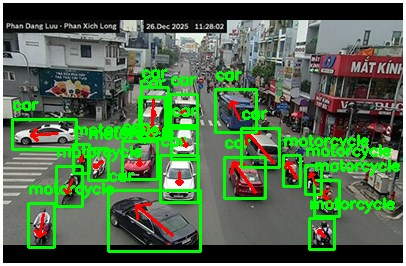

{
  "detection_data": {
    "bus_count": 1,
    "camera_id": "587ee2aeb807da0011e33d52",
    "car_count": 5,
    "motorcycle_count": 8,
    "road_area_pixels": 10363,
    "timestamp": "2025-12-26 12:33:04",
    "truck_count": 1,
    "vectors_chao_score": 0.7798622034019991
  },
  "model_prediction": {
    "congestion_score": 0.9569489928784296,
    "threshold": 0.45
  },
  "status": "success"
}


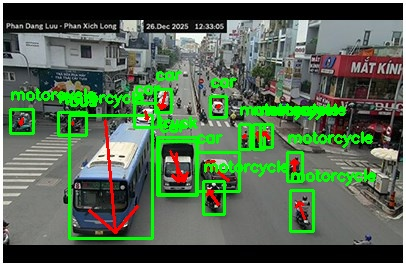

In [13]:
import requests
import json
from IPython.display import Image, display
import os
from datetime import datetime

api_url = "http://localhost:5000/realtime/realtime-score"
params = {
    "url": "https://giaothong.hochiminhcity.gov.vn:8007/Render/CameraHandler.ashx?id=587ee2aeb807da0011e33d52"
}

response = requests.get(api_url, params=params)

if response.status_code == 200:
    result = response.json()
    
    print(json.dumps(result, indent=2))
    
    if result.get("status") == "success" and "detection_data" in result:
        timestamp_str = result["detection_data"]["timestamp"]
        dt = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S")
        filename = dt.strftime("%Y%m%d_%H%M%S") + ".jpg"
        
        image_path = os.path.join("..", "..", "app", "data", "applied", filename)
        
        if os.path.exists(image_path):
            display(Image(filename=image_path))
        else:
            print(f"\nimage not found: {image_path}")
    else:
        print("\nerror: unexpected response format")
else:
    print(response.text)